In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [64]:
df_spam = pd.read_csv("../data/email_text.csv")
df_spam.head()

,label,text
0,0,the mailing list i queried about a few weeks a...
1,1,luxury watches buy your own rolex for only esc...
2,1,academic qualifications available from prestig...
3,0,greetings all this is to verify your subscript...
4,1,try chauncey may conferred the luscious not co...


In [65]:
df_spam.describe()

,label
count,17309.000000
mean,0.277370
std,0.447714
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [66]:
df_spam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17309 entries, 0 to 17308
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   17309 non-null  int64 
 1   text    17309 non-null  object
dtypes: int64(1), object(1)
memory usage: 270.6+ KB


In [67]:
print("Dataset Shape:", df_spam.shape)

Dataset Shape: (17309, 2)


In [68]:
print(df_spam.columns.tolist())

['label', 'text']


In [69]:
df_spam.isnull().sum()

label    0
text     0
dtype: int64

In [70]:
print("Empty emails:",
      (df_spam["text"].fillna("").str.strip() == "").sum())

Empty emails: 0


In [71]:
df_spam["label"].value_counts()

label
0    12508
1     4801
Name: count, dtype: int64

In [72]:
print(
    df_spam["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

label
0    72.26
1    27.74
Name: proportion, dtype: float64


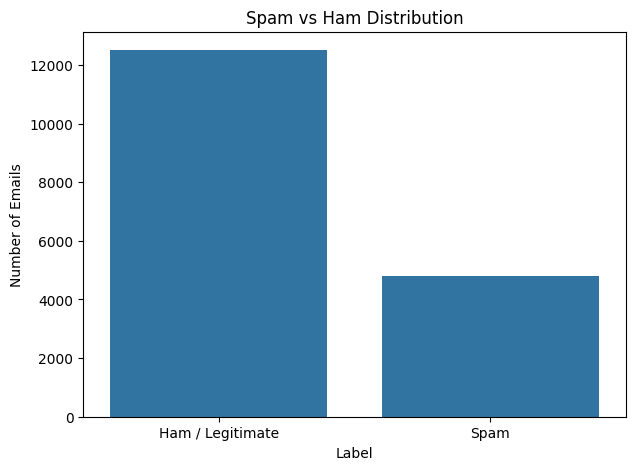

In [73]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_spam,
    x="label"
)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Emails")

plt.xticks(
    [0, 1],
    ["Ham / Legitimate", "Spam"]
)

plt.show()

In [74]:
print("Duplicate rows:", df_spam.duplicated().sum())

Duplicate rows: 0


In [75]:
print(
    "Duplicate email texts:",
    df_spam["text"].duplicated().sum()
)

Duplicate email texts: 0


In [76]:
spam_df = df_spam.copy()
spam_df = spam_df.dropna(subset=["text"])
spam_df = spam_df[
    spam_df["text"].str.strip() != ""
]
spam_df = spam_df.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)

In [77]:
print("Clean dataset shape:", spam_df.shape)

Clean dataset shape: (17309, 2)


In [78]:
spam_df["text_length"] = spam_df["text"].str.len()
spam_df["text_length"].describe()

count    1.730900e+04
mean     2.548157e+03
std      3.582312e+04
min      2.000000e+00
25%      4.240000e+02
50%      8.430000e+02
75%      1.707000e+03
max      3.140726e+06
Name: text_length, dtype: float64

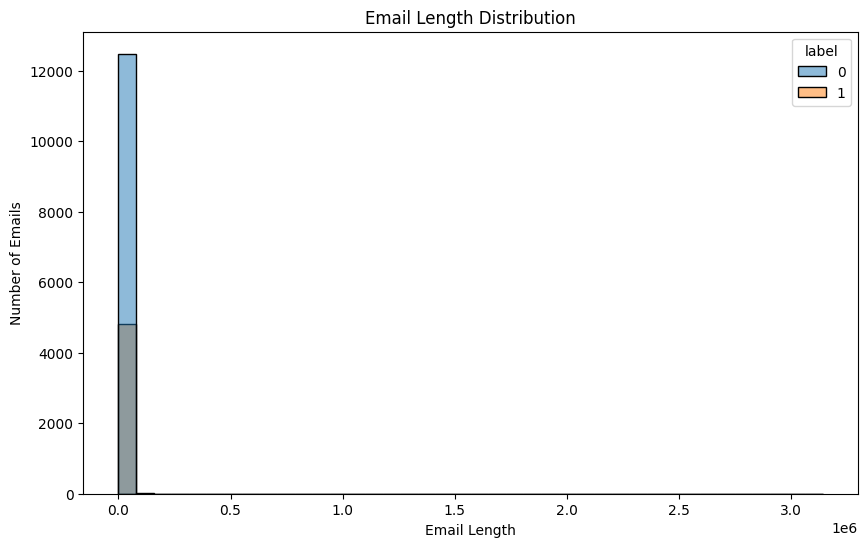

In [79]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=spam_df,
    x="text_length",
    hue="label",
    bins=40
)

plt.title("Email Length Distribution")
plt.xlabel("Email Length")
plt.ylabel("Number of Emails")

plt.show()

In [80]:
ham_examples = spam_df[
    spam_df["label"] == 0
].sample(5, random_state=42)

for _, row in ham_examples.iterrows():
    print("=" * 80)
    print(row["text"][:1500])

you don't use lynx newbies on sun escapenumber jan escapenumber drudiescapenumber aol com wrote help how do you get to the great places on the net through pine rudi nevada edu 
hi all when i run my experiemnt the cot seems not match with the total time of the images presented it's always escapenumber escapenumber ticks more i wonder whether it's because of the loading images problem or anything else thanks for help cheers vannessa this message has been checked for viruses but the contents of an attachment may still contain software viruses which could damage your computer system you are advised to perform your own checks email communications with the university of nottingham may be monitored as permitted by uk legislation 
at escapenumber escapenumber escapenumber escapenumber escapenumber escapenumber you wrote hi all i'm running a lexical decision task using a black background and white stimuli on some trials there are white dots on a line below and or above the stimulus what are the

In [81]:
spam_examples = spam_df[
    spam_df["label"] == 1
].sample(5, random_state=42)

for _, row in spam_examples.iterrows():
    print("=" * 80)
    print(row["text"][:1500])

 escapenumberd escapenumbera escapenumberd escapenumbera escapenumberd escapenumbera escapenumber vendare commercial email escapenumberd escapenumbera escapenumber escapenumberd escapenumbera escapenumberd escapenumbera escapenumberd escapenumbera escapenumberd escapenumbera escapenumberd escapenumbera escapenumberd escapenumbera escapenumber email cre ative escapenumberd escapenumbera escapenumber internal escapenumberd escapenumbera escapenumberd escapenumbera escapenumber escapenumberd escapenumbera escapenumber escapenumber escapenumberd escapenumbera escapenumber escapenumber escapenumberd escapenumbera escapenumber tr escapenumberd escapenumbera escapenumber escapenumberd escapenumbera escapenumber escapenumber escapenumberd escapenumbera escapenumber escapenumberd escapenumbera escapenumber escapenumberd escapenumbera escapenumber escapenumber td escapenumberd escapenumbera escapenumber escapenumberd escapenumbera escapenumber escapenumberd escapenumbera escapenumber escapenumbe

In [82]:
X = spam_df["text"]
y = spam_df["label"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [83]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 13847
Testing samples: 3462


In [84]:
import sys
sys.path.append("../")
from src.preprocessing import preprocess_text

In [85]:
X_train_clean = X_train.apply(preprocess_text)
X_test_clean = X_test.apply(preprocess_text)

In [86]:
print(X_train_clean.head())

12070    hi jerry certainly worked lot make everything ...
15668    begin pgp signed message hash shaescapenumber ...
9623              put plan escapenumber software page like
7901     thanks fred yes several working one download b...
12611    marshall one best set vendor price seen monarc...
Name: text, dtype: object


In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer
spam_tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)
X_train_tfidf = spam_tfidf.fit_transform(
    X_train_clean
)
X_test_tfidf = spam_tfidf.transform(
    X_test_clean
)

In [88]:
print("Training TF-IDF:", X_train_tfidf.shape)
print("Testing TF-IDF:", X_test_tfidf.shape)

Training TF-IDF: (13847, 10000)
Testing TF-IDF: (3462, 10000)


In [89]:
from sklearn.naive_bayes import MultinomialNB

spam_nb = MultinomialNB()

spam_nb.fit(
    X_train_tfidf,
    y_train
)
spam_nb_predictions = spam_nb.predict(
    X_test_tfidf
)

In [90]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
nb_spam_accuracy = accuracy_score(
    y_test,
    spam_nb_predictions
)

print(
    "Naive Bayes Spam Accuracy:",
    nb_spam_accuracy
)

Naive Bayes Spam Accuracy: 0.9364529173887927


In [91]:
print(
    classification_report(
        y_test,
        spam_nb_predictions,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.93      0.99      0.96      2502
        Spam       0.96      0.81      0.88       960

    accuracy                           0.94      3462
   macro avg       0.94      0.90      0.92      3462
weighted avg       0.94      0.94      0.93      3462



In [92]:
from sklearn.svm import LinearSVC

spam_svm = LinearSVC(
    C=1.0,
    random_state=42
)

spam_svm.fit(
    X_train_tfidf,
    y_train
)
spam_svm_predictions = spam_svm.predict(
    X_test_tfidf
)

In [93]:
svm_spam_accuracy = accuracy_score(
    y_test,
    spam_svm_predictions
)

print(
    "SVM Spam Accuracy:",
    svm_spam_accuracy
)

SVM Spam Accuracy: 0.9832466782206817


In [94]:
print(
    classification_report(
        y_test,
        spam_svm_predictions,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99      2502
        Spam       0.97      0.97      0.97       960

    accuracy                           0.98      3462
   macro avg       0.98      0.98      0.98      3462
weighted avg       0.98      0.98      0.98      3462



In [95]:
spam_comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        nb_spam_accuracy,
        svm_spam_accuracy
    ]
})

spam_comparison

,Model,Accuracy
0,Multinomial Naive Bayes,0.936453
1,Linear SVM,0.983247


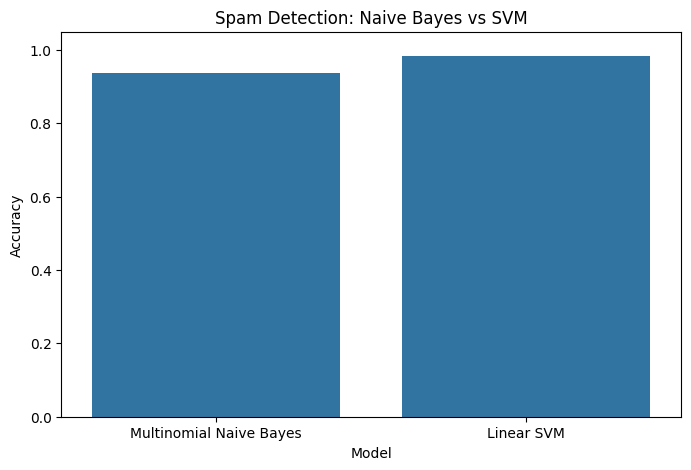

In [96]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=spam_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Spam Detection: Naive Bayes vs SVM")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)

plt.show()

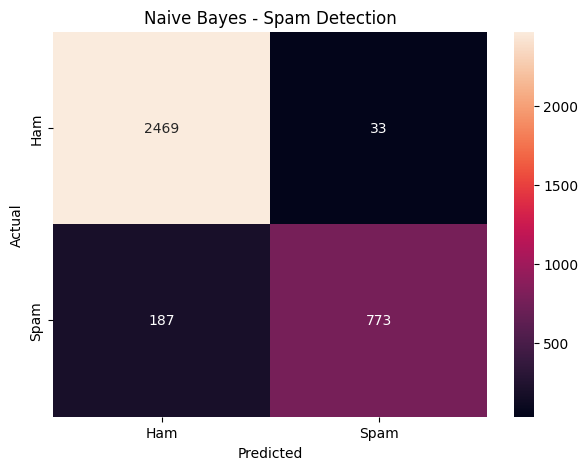

In [97]:
nb_cm = confusion_matrix(
    y_test,
    spam_nb_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Naive Bayes - Spam Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

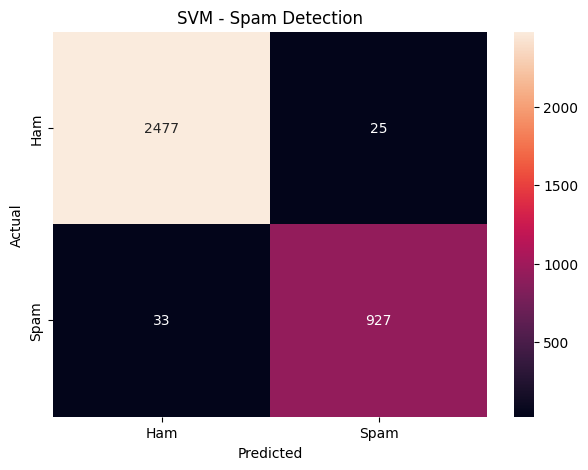

In [98]:
svm_cm = confusion_matrix(
    y_test,
    spam_svm_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("SVM - Spam Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [99]:
test_emails = [
    "Congratulations! You have won a free $10,000 prize. Click the link now to claim your reward.",
    
    "Hi Raj, can we meet tomorrow at 3 PM to discuss the project?",
    
    "Your monthly electricity bill is due on August 25. Please make the payment before the due date.",
    
    "URGENT! You have been selected for an exclusive cash reward. Send your bank details immediately.",
    
    "Please find the project report attached. Let me know if you have any feedback."
]

In [100]:
clean_test_emails = [
    preprocess_text(email)
    for email in test_emails
]

In [101]:
test_email_vectors = spam_tfidf.transform(
    clean_test_emails
)

In [102]:
predictions = spam_svm.predict(
    test_email_vectors
)

In [103]:
for email, prediction in zip(
    test_emails,
    predictions
):
    result = "SPAM" if prediction == 1 else "HAM / LEGITIMATE"

    print("=" * 80)
    print("Email:", email)
    print("Prediction:", result)

Email: Congratulations! You have won a free $10,000 prize. Click the link now to claim your reward.
Prediction: SPAM
Email: Hi Raj, can we meet tomorrow at 3 PM to discuss the project?
Prediction: HAM / LEGITIMATE
Email: Your monthly electricity bill is due on August 25. Please make the payment before the due date.
Prediction: HAM / LEGITIMATE
Email: URGENT! You have been selected for an exclusive cash reward. Send your bank details immediately.
Prediction: SPAM
Email: Please find the project report attached. Let me know if you have any feedback.
Prediction: HAM / LEGITIMATE


In [104]:
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

In [105]:
joblib.dump(
    spam_tfidf,
    models_dir / "spam_tfidf.joblib"
)

['..\\models\\spam_tfidf.joblib']

In [106]:
joblib.dump(
    spam_nb,
    models_dir / "spam_naive_bayes.joblib"
)

['..\\models\\spam_naive_bayes.joblib']

In [107]:
joblib.dump(
    spam_svm,
    models_dir / "spam_svm.joblib"
)

['..\\models\\spam_svm.joblib']

In [108]:
print("Current spam dataframe:")
print(df_spam.shape)
print(df_spam.columns.tolist())
print(df_spam.head())

Current spam dataframe:
(17309, 2)
['label', 'text']
   label                                               text
0      0  the mailing list i queried about a few weeks a...
1      1  luxury watches buy your own rolex for only esc...
2      1  academic qualifications available from prestig...
3      0  greetings all this is to verify your subscript...
4      1  try chauncey may conferred the luscious not co...


In [109]:
# ============================================================
# CREATE SPAM DATASET V2
# ============================================================

# Load legitimate emails from intent dataset
intent_df = pd.read_csv("../data/intent_emails_5000_v3.csv")

# Select email text
ham_v2 = intent_df[["text"]].copy()

# Label them as legitimate / ham
ham_v2["label"] = 0

# Make column order same as spam dataset
ham_v2 = ham_v2[["label", "text"]]

print("Additional legitimate emails:", len(ham_v2))
print(ham_v2.head())

Additional legitimate emails: 5000
   label                                               text
0      0  I wanted to confirm a few things about how to ...
1      0  I would appreciate some guidance concerning fi...
2      0  I am writing to ask about ask whether a bookin...
3      0  I am getting in touch because I need to ask ab...
4      0  Could you please help me with confirm a speake...


In [110]:
# Combine original spam dataset + legitimate intent emails

spam_v2 = pd.concat(
    [
        df_spam[["label", "text"]],
        ham_v2[["label", "text"]]
    ],
    ignore_index=True
)

# Remove duplicate emails
spam_v2 = spam_v2.drop_duplicates(
    subset="text"
).reset_index(drop=True)

print("Spam V2 shape:", spam_v2.shape)

print("\nClass distribution:")
print(spam_v2["label"].value_counts())

Spam V2 shape: (22309, 2)

Class distribution:
label
0    17508
1     4801
Name: count, dtype: int64


In [111]:
spam_v2["clean_text"] = spam_v2["text"].apply(preprocess_text)

print(spam_v2[["label", "text", "clean_text"]].head())

   label                                               text  \
0      0  the mailing list i queried about a few weeks a...   
1      1  luxury watches buy your own rolex for only esc...   
2      1  academic qualifications available from prestig...   
3      0  greetings all this is to verify your subscript...   
4      1  try chauncey may conferred the luscious not co...   

                                          clean_text  
0  mailing list queried week ago running also set...  
1  luxury watch buy rolex escapenumber rolex cart...  
2  academic qualification available prestigious n...  
3  greeting verify subscription planescapenumber ...  
4  try chauncey may conferred luscious continued ...  


In [112]:
from sklearn.model_selection import train_test_split

X_v2 = spam_v2["clean_text"]
y_v2 = spam_v2["label"]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.20,
    random_state=42,
    stratify=y_v2
)

print("Training samples:", len(X_train_v2))
print("Testing samples:", len(X_test_v2))

Training samples: 17847
Testing samples: 4462


In [113]:
from sklearn.feature_extraction.text import TfidfVectorizer

spam_tfidf_v2 = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf_v2 = spam_tfidf_v2.fit_transform(X_train_v2)
X_test_tfidf_v2 = spam_tfidf_v2.transform(X_test_v2)

print("Training TF-IDF:", X_train_tfidf_v2.shape)
print("Testing TF-IDF:", X_test_tfidf_v2.shape)

Training TF-IDF: (17847, 10000)
Testing TF-IDF: (4462, 10000)


In [114]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

spam_svm_v2 = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

spam_svm_v2.fit(
    X_train_tfidf_v2,
    y_train_v2
)

y_pred_v2 = spam_svm_v2.predict(X_test_tfidf_v2)

print("Spam V2 Accuracy:", accuracy_score(y_test_v2, y_pred_v2))

print("\nClassification Report:")
print(classification_report(y_test_v2, y_pred_v2))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_v2, y_pred_v2))

Spam V2 Accuracy: 0.9818467055132227

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3502
           1       0.94      0.97      0.96       960

    accuracy                           0.98      4462
   macro avg       0.97      0.98      0.97      4462
weighted avg       0.98      0.98      0.98      4462


Confusion Matrix:
[[3445   57]
 [  24  936]]


In [115]:
test_emails_v2 = [
    "I wanted to follow up on my job application and ask about the next interview stage.",
    
    "Could you send me the invoice for last month's payment?",
    
    "I am having an issue with my account and need some assistance.",
    
    "Could you please review the updated business proposal and send me your feedback?",
    
    "Could you please confirm our meeting scheduled for tomorrow at 3 PM?",
    
    "Are you free for dinner this weekend? It would be nice to catch up.",
    
    "Congratulations! You have won $10,000. Click here immediately to claim your prize!",
    
    "URGENT! You have been selected to receive $10,000. Claim your reward immediately!",
    
    "You have won a free vacation! Click this link now to claim your prize."
]

test_clean = [preprocess_text(x) for x in test_emails_v2]

test_vectors = spam_tfidf_v2.transform(test_clean)

predictions = spam_svm_v2.predict(test_vectors)
scores = spam_svm_v2.decision_function(test_vectors)

for email, prediction, score in zip(
    test_emails_v2,
    predictions,
    scores
):
    label = "SPAM" if prediction == 1 else "LEGITIMATE"

    print("=" * 80)
    print("Email:", email)
    print("Prediction:", label)
    print("Score:", round(score, 4))

Email: I wanted to follow up on my job application and ask about the next interview stage.
Prediction: LEGITIMATE
Score: -0.4312
Email: Could you send me the invoice for last month's payment?
Prediction: SPAM
Score: 0.4518
Email: I am having an issue with my account and need some assistance.
Prediction: SPAM
Score: 0.7069
Email: Could you please review the updated business proposal and send me your feedback?
Prediction: LEGITIMATE
Score: -0.3465
Email: Could you please confirm our meeting scheduled for tomorrow at 3 PM?
Prediction: LEGITIMATE
Score: -0.7933
Email: Are you free for dinner this weekend? It would be nice to catch up.
Prediction: SPAM
Score: 0.3281
Email: Congratulations! You have won $10,000. Click here immediately to claim your prize!
Prediction: SPAM
Score: 2.1201
Email: URGENT! You have been selected to receive $10,000. Claim your reward immediately!
Prediction: SPAM
Score: 1.4936
Email: You have won a free vacation! Click this link now to claim your prize.
Prediction:

In [116]:
# ============================================================
# V2 THRESHOLD ANALYSIS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Get decision scores
v2_scores = spam_svm_v2.decision_function(X_test_tfidf_v2)

thresholds = [
    0.0,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.0,
    1.1,
    1.2,
    1.3,
    1.4,
    1.5
]

print("=" * 100)
print("SPAM V2 THRESHOLD ANALYSIS")
print("=" * 100)

print(
    f"{'Threshold':<12}"
    f"{'Accuracy':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
    f"{'False Pos':<12}"
    f"{'False Neg':<12}"
)

for threshold in thresholds:

    predictions = (v2_scores >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_v2,
        predictions,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(y_test_v2, predictions)
    precision = precision_score(
        y_test_v2,
        predictions,
        zero_division=0
    )
    recall = recall_score(
        y_test_v2,
        predictions,
        zero_division=0
    )
    f1 = f1_score(
        y_test_v2,
        predictions,
        zero_division=0
    )

    print(
        f"{threshold:<12.1f}"
        f"{accuracy:<12.4f}"
        f"{precision:<12.4f}"
        f"{recall:<12.4f}"
        f"{f1:<12.4f}"
        f"{fp:<12}"
        f"{fn:<12}"
    )

SPAM V2 THRESHOLD ANALYSIS
Threshold   Accuracy    Precision   Recall      F1          False Pos   False Neg   
0.0         0.9818      0.9426      0.9750      0.9585      57          24          
0.1         0.9834      0.9548      0.9688      0.9617      44          30          
0.2         0.9839      0.9664      0.9583      0.9623      32          40          
0.3         0.9848      0.9745      0.9542      0.9642      24          44          
0.4         0.9836      0.9784      0.9448      0.9613      20          53          
0.5         0.9794      0.9801      0.9229      0.9506      18          74          
0.6         0.9693      0.9858      0.8698      0.9242      12          125         
0.7         0.9639      0.9866      0.8438      0.9096      11          150         
0.8         0.9583      0.9886      0.8156      0.8938      9           177         
0.9         0.9494      0.9906      0.7719      0.8677      7           219         
1.0         0.9339      0.9911      0.

In [117]:
print("\n" + "=" * 80)
print("REAL-WORLD THRESHOLD TEST")
print("=" * 80)

for threshold in [0.0, 0.5, 0.7, 0.8, 1.0]:

    print("\n" + "-" * 80)
    print("THRESHOLD:", threshold)

    for email, score in zip(test_emails_v2, scores):

        prediction = 1 if score >= threshold else 0

        label = "SPAM" if prediction == 1 else "LEGITIMATE"

        print(
            f"{label:<12} | "
            f"{score:>7.4f} | "
            f"{email}"
        )


REAL-WORLD THRESHOLD TEST

--------------------------------------------------------------------------------
THRESHOLD: 0.0
LEGITIMATE   | -0.4312 | I wanted to follow up on my job application and ask about the next interview stage.
SPAM         |  0.4518 | Could you send me the invoice for last month's payment?
SPAM         |  0.7069 | I am having an issue with my account and need some assistance.
LEGITIMATE   | -0.3465 | Could you please review the updated business proposal and send me your feedback?
LEGITIMATE   | -0.7933 | Could you please confirm our meeting scheduled for tomorrow at 3 PM?
SPAM         |  0.3281 | Are you free for dinner this weekend? It would be nice to catch up.
SPAM         |  2.1201 | Congratulations! You have won $10,000. Click here immediately to claim your prize!
SPAM         |  1.4936 | URGENT! You have been selected to receive $10,000. Claim your reward immediately!
SPAM         |  1.8049 | You have won a free vacation! Click this link now to claim your p

In [118]:
threshold = 0.8

v2_predictions_08 = (
    spam_svm_v2.decision_function(X_test_tfidf_v2) >= threshold
).astype(int)

print("Threshold:", threshold)

print("\nAccuracy:")
print(accuracy_score(y_test_v2, v2_predictions_08))

print("\nClassification Report:")
print(
    classification_report(
        y_test_v2,
        v2_predictions_08,
        target_names=["Legitimate", "Spam"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_v2,
        v2_predictions_08
    )
)

Threshold: 0.8

Accuracy:
0.9583146571044374

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.95      1.00      0.97      3502
        Spam       0.99      0.82      0.89       960

    accuracy                           0.96      4462
   macro avg       0.97      0.91      0.93      4462
weighted avg       0.96      0.96      0.96      4462


Confusion Matrix:
[[3493    9]
 [ 177  783]]


In [119]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

# Save V2 SVM
joblib.dump(
    spam_svm_v2,
    MODEL_DIR / "spam_svm_v2.joblib"
)

# Save V2 TF-IDF
joblib.dump(
    spam_tfidf_v2,
    MODEL_DIR / "spam_tfidf_v2.joblib"
)

print("Spam V2 model saved successfully.")
print(MODEL_DIR / "spam_svm_v2.joblib")
print(MODEL_DIR / "spam_tfidf_v2.joblib")

Spam V2 model saved successfully.
..\models\spam_svm_v2.joblib
..\models\spam_tfidf_v2.joblib
